# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

I (jimmy :]) use MCMC to compute the effects of suppressing tail terms (1.5-3.5PN order, encompassing first-order tails to 2nd-order nonlinear Christodoulou memory) in the waveform. Of interest are the Bayes factor between the untouched waveform and variously suppressed waveforms as a multivariate function of the toggling parameters (lambda15 thru lambda35).

## PN Terms by Order
- 1.5PN: first-order tail term; 
- 2.5PN: Christodoulou memory term and corrections to the 1.5PN tail term; 
- 3PN: second-order tail/tail-of-tail term; 
- 3.5PN: Christodoulou memory correction

In [5]:
import lambdasMCMC as lmcmc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
## Only NEED the <lnL> vs beta plot, but DO write functionality to make diagnostic plots like: 
# time/freq-series strain,
# \Delta\Psi vs f, **STARTED
# lnL vs iteration, **STARTED
# \vec{\theta} vs iteration, **STARTED
# MAYBE posterior corner plots (for 1-2 arbitrary sets of toggle params) and bayesograms
## Figure out how to calculate lnZ's later
num_samples=30000
num_chains=15


######### Running PTMCMC #1/2 for lambdavec=$\lambda15$=0.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########
Jump acceptance rates
Fisher_jump: [0.6868545  0.69098571 0.68619351 0.6700818  0.6796662  0.66727258
 0.66520697 0.6526481  0.64975626 0.6533091  0.63645377 0.63843675
 0.6338098  0.62703462 0.62191192]
DE_jump: [0.00891073 0.00982678 0.01115923 0.00999334 0.01015989 0.01249167
 0.01065956 0.01057628 0.01065956 0.01232512 0.01099267 0.01190873
 0.01232512 0.01132578 0.01274151]
PT_swap: [0.75866168 0.76307745 0.74592391 0.75747283 0.74575408 0.76002038
 0.76205842 0.75169837 0.74643342 0.75577446 0.76188859 0.77055027
 0.7747962  0.75305707 0.        ]
Chain 1 (T=1.0):
 	<lnL>_2-<lnL>_1=-0.8809385291227709,
 	alpha(sigma_1+sigma_2)=3.96504167526773,
 	overlap w/ chain 2? True
Chain 2 (T=1.3):
 	<lnL>_3-<lnL>_2=-1.191423302304476,
 	alpha(sigma_2+sigma_3)=5.15821676904773,
 	overlap w/ chain 3? True
Chain 3 (T=1.69):
 	<lnL>_4-<lnL>_3=-1.5793067082872287,
 	alpha(sigm

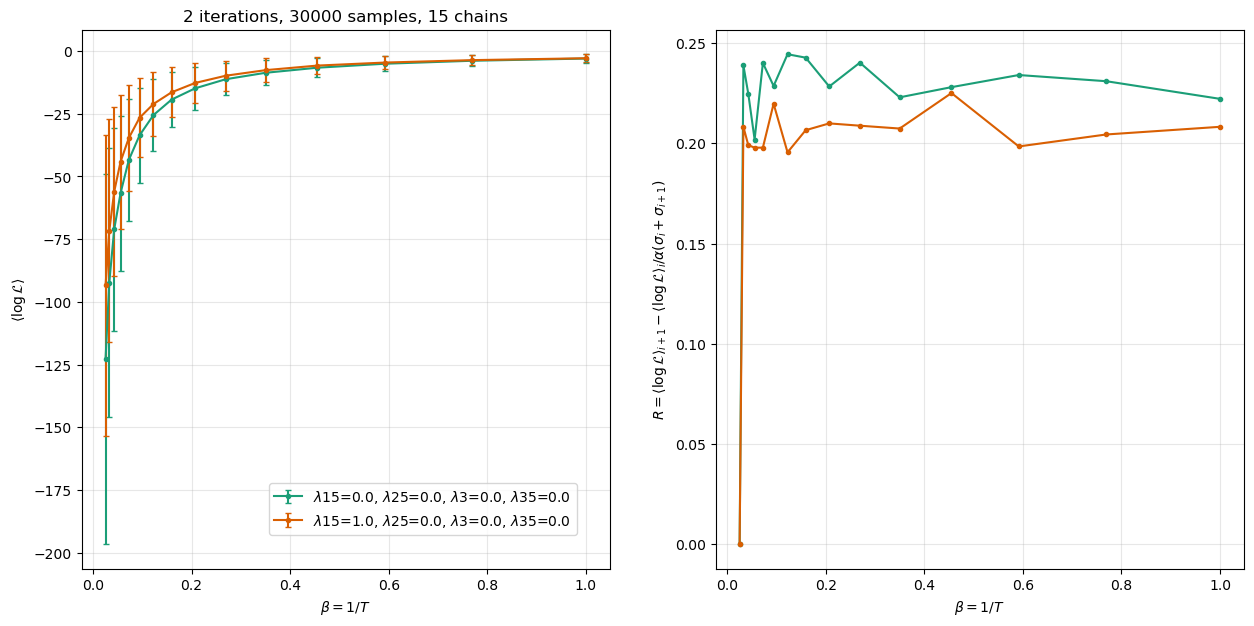

In [ ]:
lambdas=list(zip(lmcmc.lambda15s, lmcmc.lambda25s, lmcmc.lambda3s, lmcmc.lambda35s))
num_lmcmciters=len(lambdas)

fig,(ax1, ax2) = plt.subplots(1,2, figsize=(15,7))
colors=lmcmc.itercolors

i=1
for lambda15, lambda25, lambda3, lambda35 in lambdas:
    lambdavec=f'$\lambda15$={round(lambda15,2)}, $\lambda25$={round(lambda25,2)}, $\lambda3$={round(lambda3,2)}, $\lambda35$={round(lambda35,2)}'
    print(f'######### Running PTMCMC #{i}/{num_lmcmciters} for lambdavec={lambdavec} #########')

    ## Do PTMCMC for this set of lambda values
    samples, lnposts, temp_ladder, acc_rates = lmcmc.PTMCMC_i(lambdas=[lambda15, lambda25, lambda3, lambda35], 
                                                   num_samples=num_samples,
                                                   num_chains=num_chains,
                                                   temp0=1.3)

    # Plot results
    betas, avg_lnlikes, lnlikes_stdevs = lmcmc.avglnlikes_vs_betas(temp_ladder, lnposts, num_samples)
    ax1.errorbar(betas, avg_lnlikes, yerr=lnlikes_stdevs, capsize=2, marker='.', color=colors[i-1], label=lambdavec)
    
    ## Inspect ladder spacing    
    B,R=lmcmc.ladder_spacing(temp_ladder, avg_lnlikes, lnlikes_stdevs, alpha=1, print_chains=True, haxis='B')
    ax2.plot(B,R, marker='.', color=colors[i-1], label=lambdavec)

    avgPTswapaccrate=np.mean(acc_rates['PT_swap'][:-1])
    print(f'Average PT swap acceptance rate: {avgPTswapaccrate}')

    ## Perform thermodynamic integration w/ Akima splining (?)
    # ...
    
    # Calculate bayes factor WRT unsuppressed waveform
    # ...

    i+=1 # finish iteration


# Decorate the plots :)
fig.set_title(f'{num_lmcmciters} iterations, {num_samples} samples, {num_chains} chains')
ax1.set_xlabel(r'$\beta = 1 / T$')
ax1.set_ylabel(r'$\langle\log\mathcal{L}\rangle$')
ax1.legend(loc='lower right', bbox_to_anchor=(0.95, 0.05))

ax2.set_xlabel(r'$\beta = 1 / T$')
ax2.set_ylabel(r'$R = (\langle\log\mathcal{L}\rangle_{i+1}-\langle\log\mathcal{L}\rangle_{i}) / \alpha(\sigma_{i}+\sigma_{i+1})$')

for ax in (ax1, ax2):
    ax.grid(alpha=0.3)

plt.show()